In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first

# from kret_lgbm._core.lgbm_nb_imports import *
# from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *

# from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *

# from kret_sklearn._core.sklearn_nb_imports import *
# from kret_torch_utils._core.torch_nb_imports import *
# from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 2.9872 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0006 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_type_hints._core.types_nb_imports] Imported kret_type_hints._core.types_nb_imports in 0.0009 seconds
[kret_utils._core.utils_nb_imports] Imported kret_utils._core.utils_nb_imports in 0.0067 seconds


In [3]:
from nba_timeout_impact.nb_imports import *

# TV / mandatory timeout study

Two questions:

1. **Visual evidence** that mandatory timeouts in cdnnba (post-2017) already exist as ordinary `subType="full"` rows, clustering at the rulebook trigger marks.
2. **Reclassification** of each timeout row's role (slot_K_mandatory / slot_K_absorbed / discretionary / challenge), tested on the v3 labeled era (1998-2016) against ground-truth `Official` / `Official TV` subTypes.

# Load data

In [4]:
from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.datasets.memo_cdnnba_pl import CDNNBAMemoPL
from nba_timeout_impact.data_pipes.tv_timeout_injection import TVTimeoutValidation

memo_v3 = NBAMemoDF.load_all()  # nbastatsv3 + nbastats v2 (~1s)
memo_cdn = CDNNBAMemoPL.load_all()  # cdnnba post-2017 (~3s)

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 77 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


# Part 1 — Density of cdnnba timeouts by clock bin

The cdnnba memo has a parameterized `sr_bin(width)` column. Plot the
density of `full` and `challenge` timeouts at 15s / 30s / 60s resolutions
to see where they cluster relative to the rulebook trigger marks (7:00
and 3:00 = sr=420 and sr=180).

Calculating bin_sr(15,)
Calculating bin_sr(30,)
Calculating bin_sr(60,)


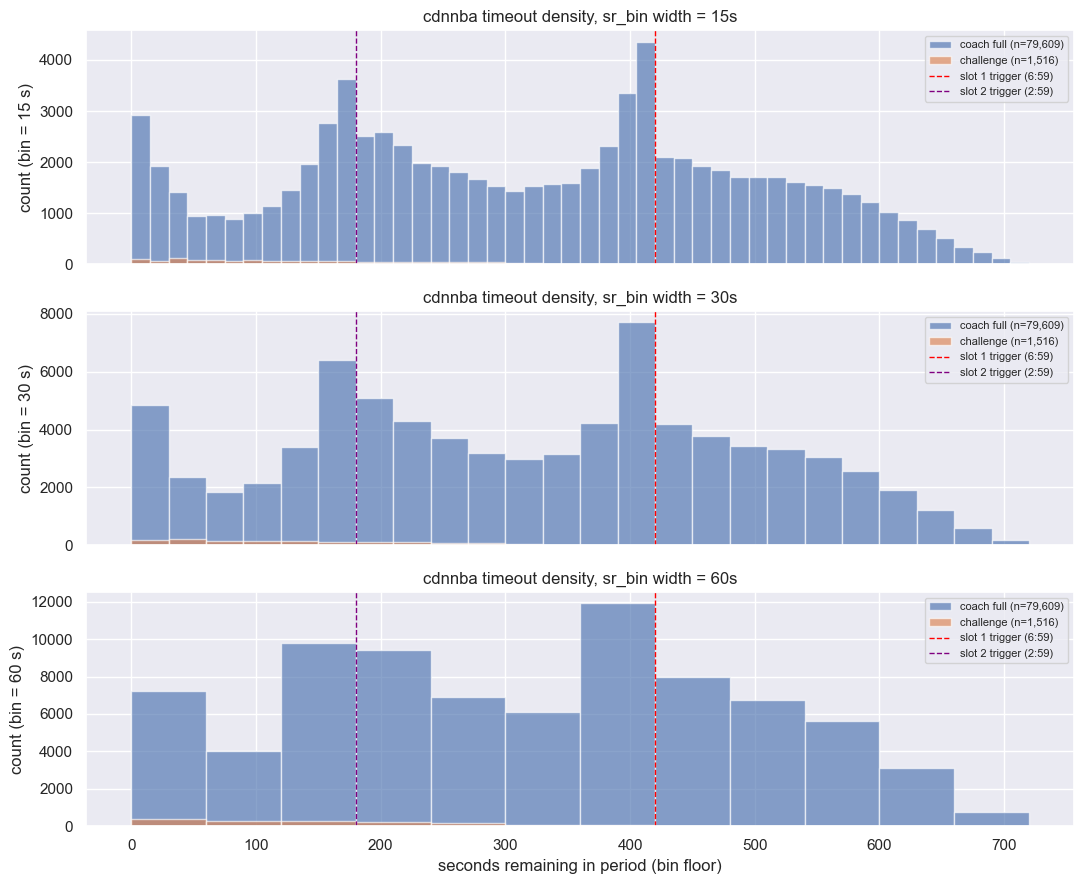

In [5]:
df = pl.DataFrame._from_pydf(memo_cdn.cdnnba._df)
df = df.filter((pl.col("actionType") == "timeout") & pl.col("period").is_in([1, 2, 3, 4]))

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, width in zip(axes, [15, 30, 60]):
    binned = df.with_columns(memo_cdn.bin_sr(width).gather(df["orderNumber"] - df["orderNumber"]))  # dummy alignment
    # simpler: just compute bins directly here
    bins = (df["seconds_remaining"] // width * width).cast(pl.Int32)
    df2 = df.with_columns(bins.alias("sr_bin"))
    for sub, color, label in [("full", "C0", "coach full"), ("challenge", "C1", "challenge")]:
        vals = df2.filter(pl.col("subType") == sub)["sr_bin"].to_numpy()
        if len(vals) == 0:
            continue
        ax.hist(
            vals, bins=np.arange(0, 720 + width, width), alpha=0.65, label=f"{label} (n={len(vals):,})", color=color
        )
    ax.axvline(420, color="red", linestyle="--", linewidth=1, label="slot 1 trigger (6:59)")
    ax.axvline(180, color="purple", linestyle="--", linewidth=1, label="slot 2 trigger (2:59)")
    ax.set_ylabel(f"count (bin = {width} s)")
    ax.set_title(f"cdnnba timeout density, sr_bin width = {width}s")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("seconds remaining in period (bin floor)")
plt.tight_layout()
plt.show()

# Part 3 - cdnnba classification 

Examine the cdnnba data and predictions


## Plots

In [6]:
seasons = None  # (2020, 2025)
cdn_pl = TVTimeoutValidation._prep_cdnnba(memo_cdn, seasons=seasons)
classified = TVTimeoutValidation.classify_timeouts(cdn_pl, source="cdnnba", seasons=seasons)

In [7]:
# # Validation
# r = TVTimeoutValidation.validate_against_cdnnba(memo_cdn, seasons=seasons)
# print(r.summary())  # F1=1.000 (predicting from the same signal we score on)

# # Confusion matrix
# TVTimeoutValidation.confusion_matrix_cdnnba(memo_cdn, seasons=seasons)

In [8]:
figs = TimeoutInjectionPlots.diagnose_cdnnba(classified, full_pbp_pl=memo_cdn)

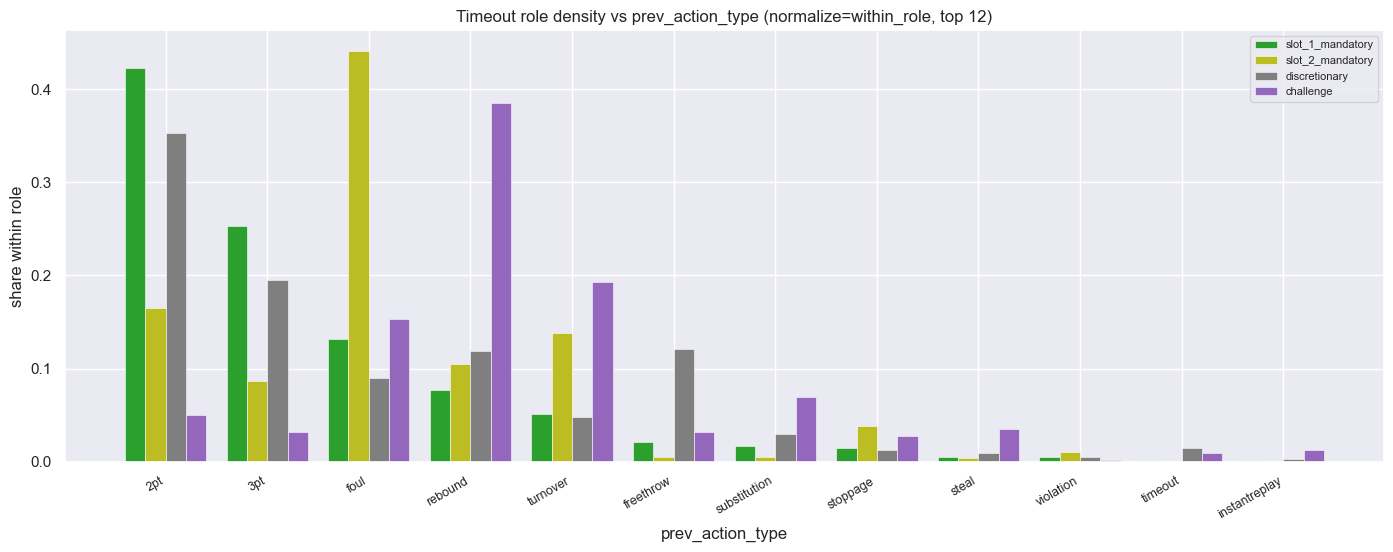

In [9]:
figs["role_vs_prev_action_type"]

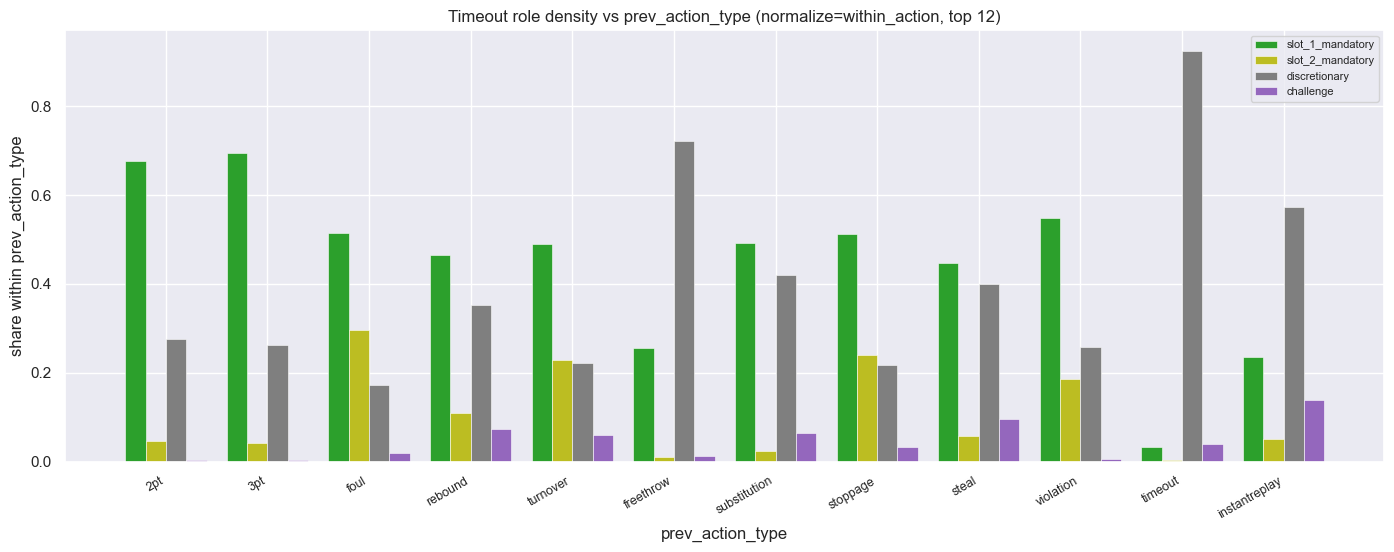

In [10]:
fig, ax, mat = TimeoutInjectionPlots.plot_role_vs_prev_action_type(
    classified, memo_cdn, normalize="within_action"  # "given X happened, what fraction of TOs are mandatory?"
)
fig

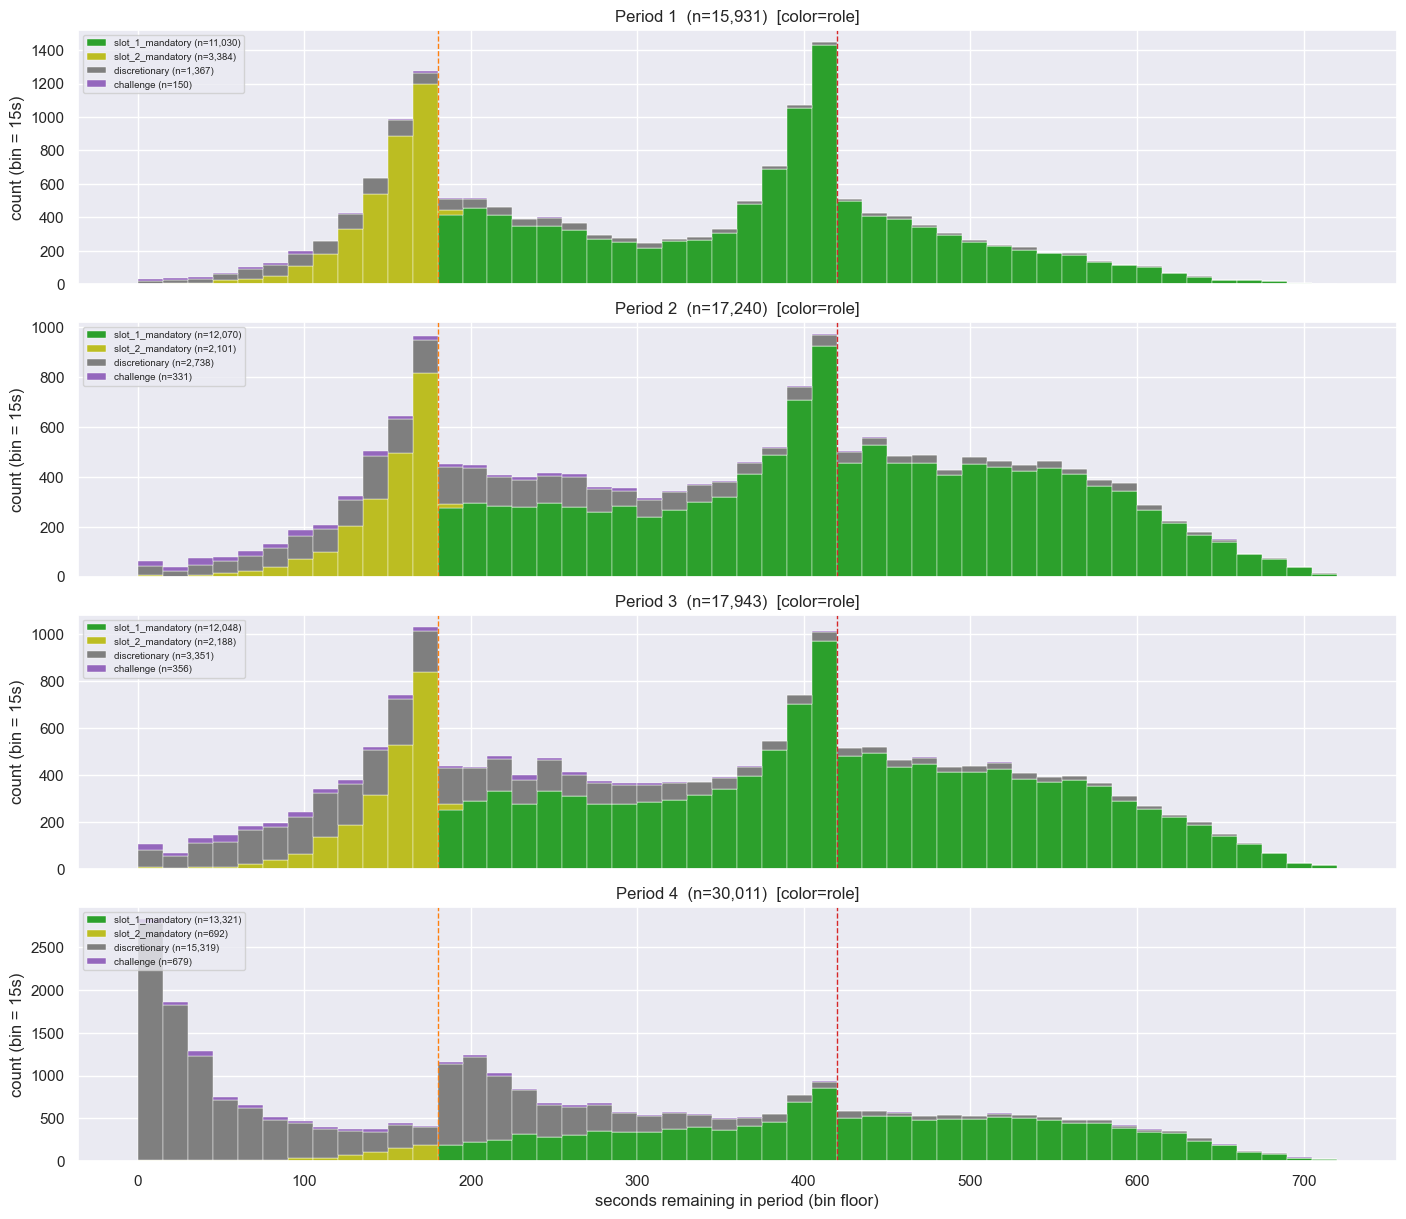

In [11]:
figs["role_vs_sr"]

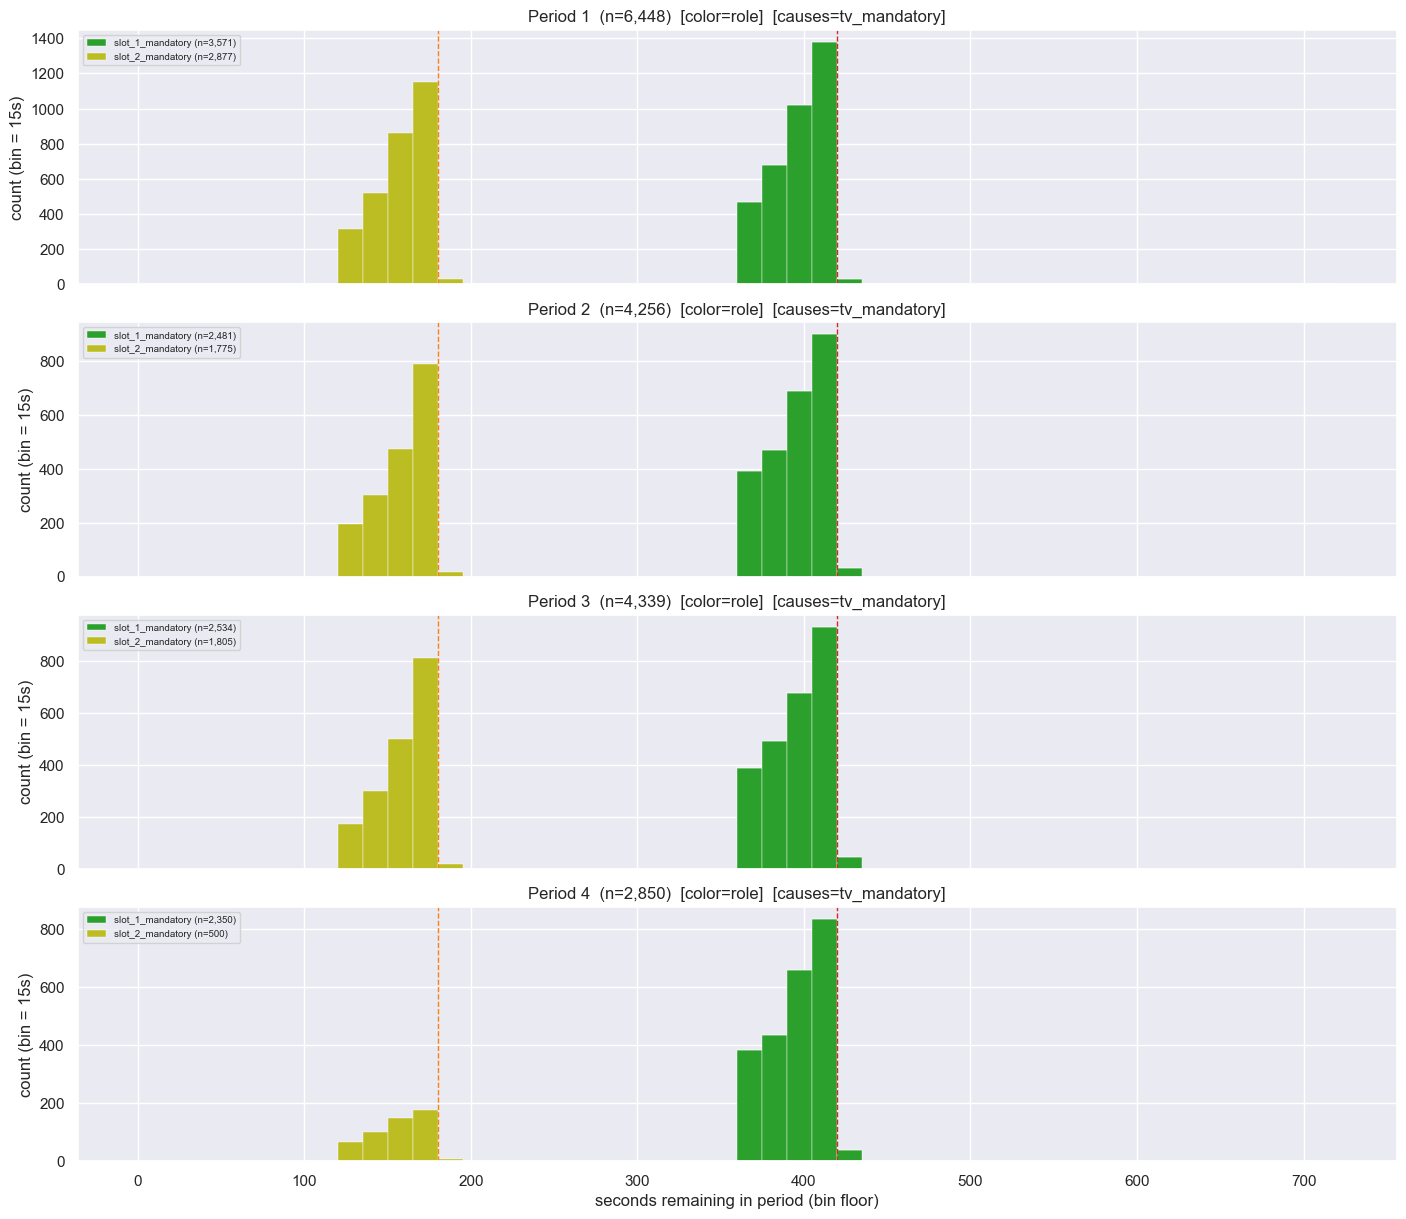

In [12]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",))
fig

In [13]:
classified["timeout_cause"].value_counts()

timeout_cause,count
str,u32
"""tv_mandatory""",17894
"""challenge""",1555
"""coach_discretionary""",23747
"""coach_preempt""",6344
"""coach_absorb""",32657
"""""",4086589


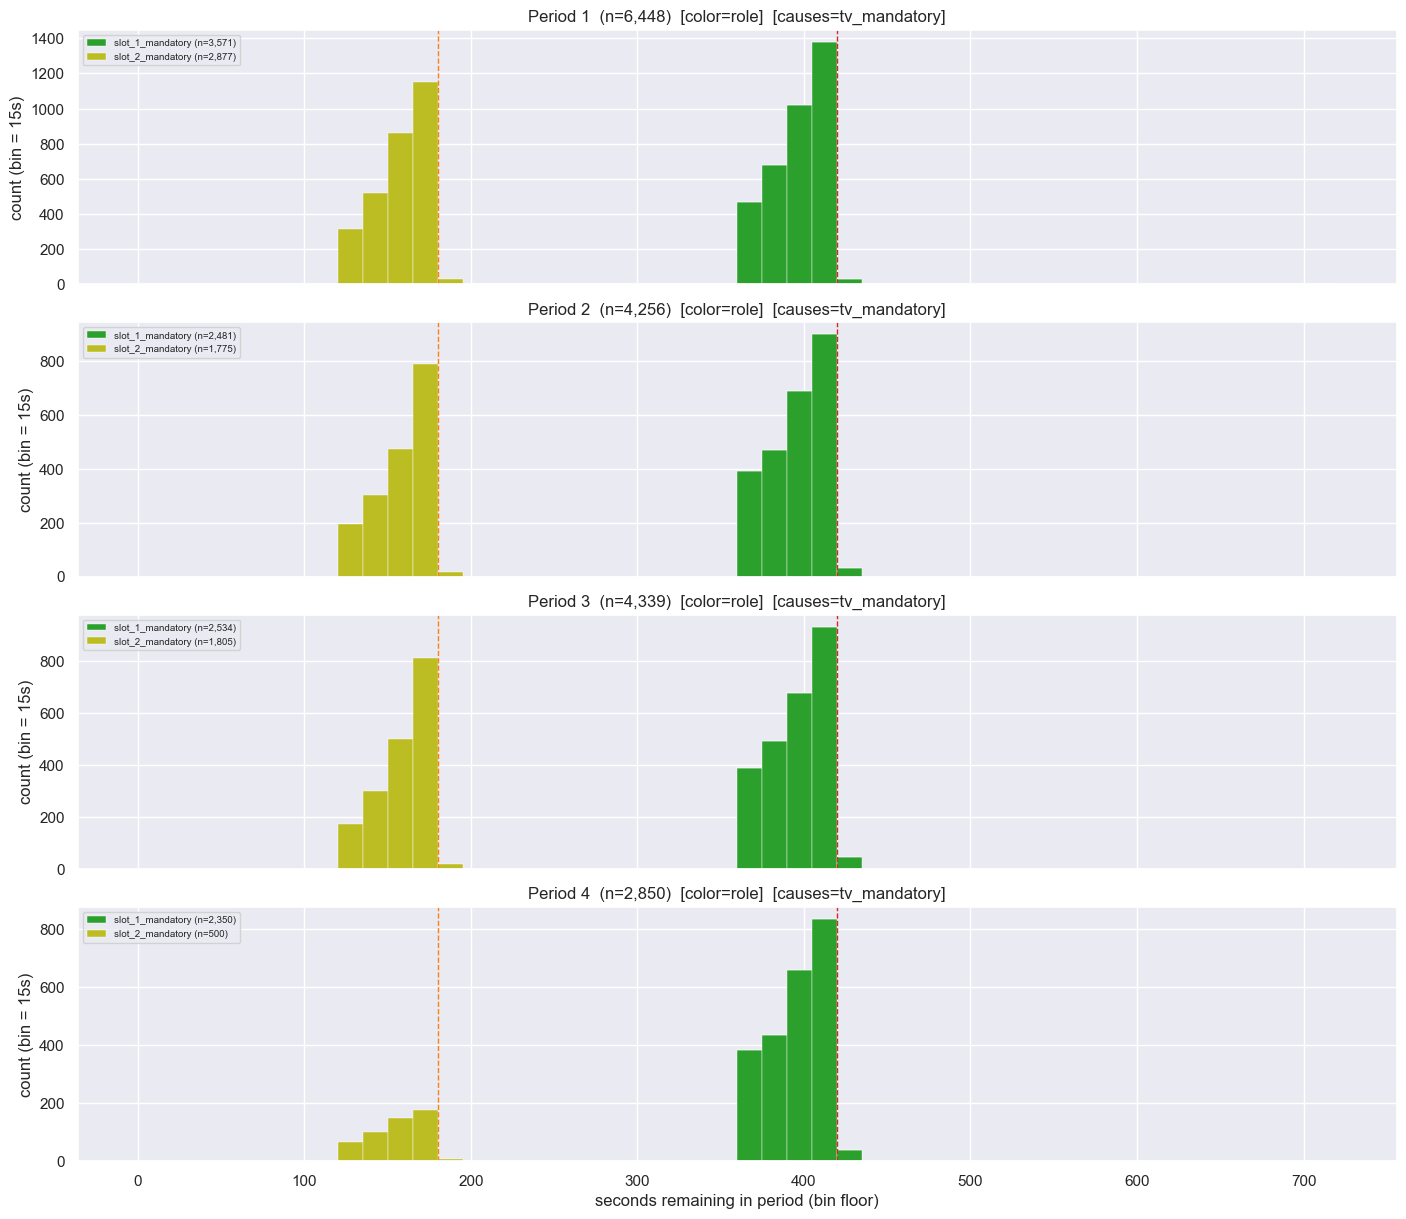

In [14]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",))
fig

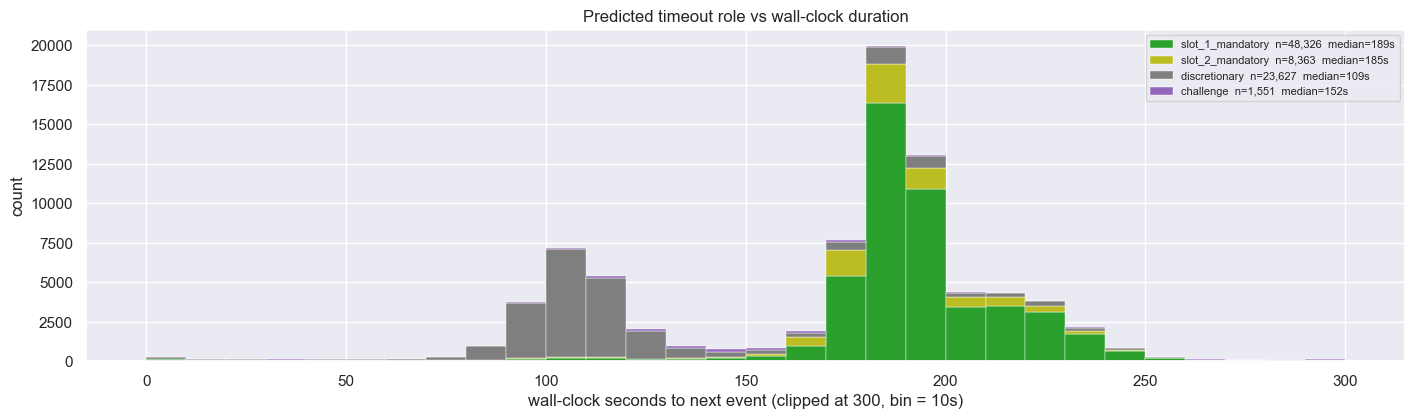

In [15]:
figs["role_vs_duration"]

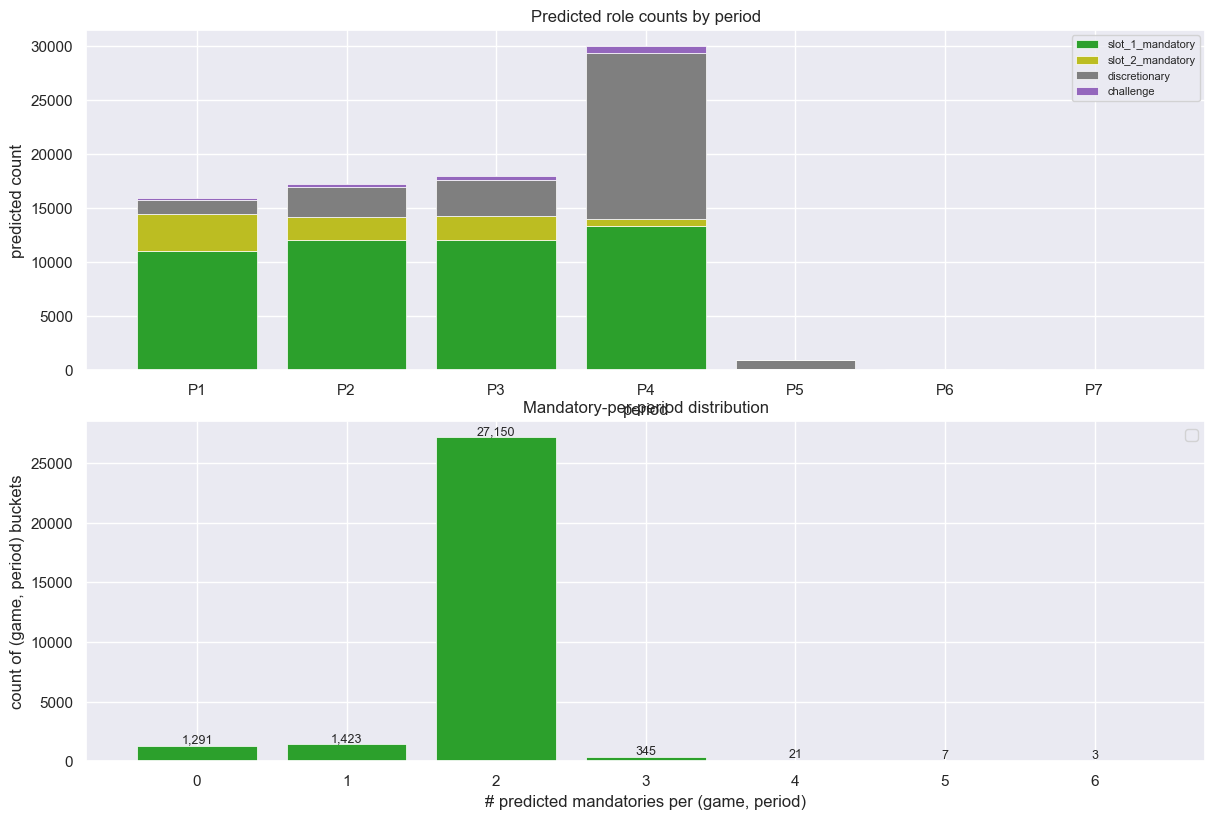

In [16]:
figs["role_counts_per_period"]

In [17]:
# figs["team_mandatory_share"]

# Sandbox

In [18]:
UKS_NP_PD.dtt(
    [
        memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    # filter=f_nearby,
    # highlight_filter=f_index,
    how="sample",
    n=4,
    seed=0,
)

Calculating f_timeout


game_date 
 gameId 
 orderNumber 
 actionType 
 subType 
 description 
 scoreHome 
 scoreAway 
 pointsTotal 
 possession 
 period 
 game_seconds_elapsed 
 seconds_remaining 
 seconds_elapsed 
 IsPlayoff 
 periodType 
 qualifiers 
 edited 
 isFieldGoal 
 side 
 personIdsFilter 
 teamTricode 
 descriptor 
 jumpBallRecoveredName 
 jumpBallWonPlayerName 
 jumpBallWonPersonId 
 jumpBallLostPlayerName 
 jumpBallLostPersonId 
 officialId 
 turnoverTotal 
 foulPersonalTotal 
 foulTechnicalTotal 
 foulDrawnPlayerName 
 foulDrawnPersonId 
 shotResult 
 assistPlayerNameInitial 
 assistPersonId 
 assistTotal 
 shotActionNumber 
 reboundTotal 
 reboundDefensiveTotal 
 reboundOffensiveTotal 
 blockPlayerName 
 blockPersonId 
 jumpBallRecoverdPersonId 
 stealPlayerName 
 stealPersonId 
 area 
 areaDetail 
 isTargetScoreLastPeriod 
 playerNameI 
 actionNumber 
 clock 
 timeActual 
 teamId 
 personId 
 playerName 
 xLegacy 
 yLegacy 
 x 
 y 
 shotDistance 
 season_type 
 season 
 shot_value 
 points_scored 
 score_margin 
 is_clutch 
 prev_action_type 
 x_court 
 y_court 
 possession_id 
 possession_points 
 possession_outcome 
 timeout_duration_s 
 timeout_role 
 timeout_cause 
 
 
 
 datetime64[ms] 
 int64 
 int64 
 category 
 category 
 str 
 int64 
 int64 
 float64 
 int64 
 int64 
 float64 
 float64 
 float64 
 bool 
 category 
 str 
 datetime64[us, UTC] 
 int64 
 category 
 str 
 category 
 str 
 str 
 str 
 float64 
 str 
 float64 
 float64 
 float64 
 float64 
 float64 
 str 
 float64 
 category 
 str 
 float64 
 float64 
 float64 
 float64 
 float64 
 float64 
 str 
 float64 
 float64 
 str 
 float64 
 category 
 category 
 object 
 category 
 int64 
 str 
 datetime64[us, UTC] 
 float64 
 int64 
 category 
 float64 
 float64 
 float64 
 float64 
 float64 
 str 
 int64 
 float64 
 int64 
 int64 
 bool 
 category 
 float64 
 float64 
 float64 
 float64 
 str 
 float64 
 str 
 str 
 
 
 
 
 2408749 
 2024-01-06 
 22300491 
 4570000 
 timeout 
 full 
 MEM Timeout 
 91 
 88 
 NaN 
 1610612763 
 3 
 2050.000 
 110.000 
 610.000 
 False 
 REGULAR 
 team, mandatory 
 2024-01-06 04:52:06+00:00 
 0 
 NaN 
 NaN 
 MEM 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 False 
 NaN 
 460 
 PT01M50.00S 
 2024-01-06 04:52:06.700000+00:00 
 1610612763.000 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 rg 
 2023 
 NaN 
 0 
 3 
 False 
 turnover 
 NaN 
 NaN 
 154.000 
 0.000 
 turnover_dead 
 213.000 
 slot_2_mandatory 
 coach_absorb 
 
 
 2875325 
 2024-10-31 
 22400127 
 3660000 
 timeout 
 full 
 POR Timeout 
 67 
 70 
 NaN 
 1610612757 
 3 
 1709.000 
 451.000 
 269.000 
 False 
 REGULAR 
 team, mandatory 
 2024-10-31 03:56:49+00:00 
 0 
 NaN 
 NaN 
 POR 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 False 
 NaN 
 373 
 PT07M31.00S 
 2024-10-31 03:56:49.300000+00:00 
 1610612757.000 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 rg 
 2024 
 NaN 
 0 
 -3 
 False 
 2pt 
 NaN 
 NaN 
 116.000 
 0.000 
 turnover_dead 
 187.000 
 slot_1_mandatory 
 coach_absorb 
 
 
 3856097 
 2025-12-31 
 22500461 
 5490000 
 timeout 
 full 
 SAC Timeout 
 115 
 76 
 NaN 
 1610612758 
 4 
 2442.000 
 438.000 
 282.000 
 False 
 REGULAR 
 team, mandatory 
 2025-12-31 06:05:06+00:00 
 0 
 NaN 
 NaN 
 SAC 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 False 
 NaN 
 552 
 PT07M18.00S 
 2025-12-31 06:05:06.900000+00:00 
 1610612758.000 
 0 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 NaN 
 rg 
 2025 
 NaN 
 0 
 39 
 False 
 2pt 
 NaN 
 NaN 
 158.000 
 0.000 
 miss 
 191.000 
 slot_1_mandatory 
 coach_preempt 
 
 
 4025386 
 2026-02-08 
 22500756 
 6340000 
 timeout 
 full 
 SAC Timeout 
 123 
 126 
 NaN 
 1610612758 
 4 
 2803.000 
 77.000 
 643.000 
 False 

In [19]:
index = [360]
f_index = np.zeros(len(memo_cdn.cdnnba), dtype=bool)
f_index[index] = True

In [20]:
f_nearby = UKS_NP_PD.get_nearby_rows(
    memo_cdn.cdnnba, f_index, hard_match=["gameId", "period"], soft_match={"seconds_elapsed": (60, "backward")}
)
f_nearby.sum()

np.int64(13)

In [21]:
UKS_NP_PD.dtt(
    [
        memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    # filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    filter=f_nearby,
    highlight_filter=f_index,
    how="head",
    n=20,
)

,game_date,gameId,orderNumber,actionType,subType,description,scoreHome,scoreAway,pointsTotal,possession,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,IsPlayoff,periodType,qualifiers,edited,isFieldGoal,side,personIdsFilter,teamTricode,descriptor,jumpBallRecoveredName,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,officialId,turnoverTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,shotResult,assistPlayerNameInitial,assistPersonId,assistTotal,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,blockPlayerName,blockPersonId,jumpBallRecoverdPersonId,stealPlayerName,stealPersonId,area,areaDetail,isTargetScoreLastPeriod,playerNameI,actionNumber,clock,timeActual,teamId,personId,playerName,xLegacy,yLegacy,x,y,shotDistance,season_type,season,shot_value,points_scored,score_margin,is_clutch,prev_action_type,x_court,y_court,possession_id,possession_points,possession_outcome,timeout_duration_s,timeout_role,timeout_cause
348,2020-12-23 00:00:00,22000001,3920000,2pt,Hook,MISS J. Wiseman 7' Hook,73,49,nan,1610612744,3,1603.000000,557.000000,163.000000,False,REGULAR,pointsinthepaint,2020-12-23 01:27:17+00:00,1,right,1630164,GSW,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,Missed,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,J. Wiseman,408,PT09M17.00S,2020-12-23 01:27:09.100000+00:00,1610612744.000000,1630164,Wiseman,0.000000,74.000000,86.547306,50.068934,7.400000,rg,2020,2.000000,0,24,False,freethrow,0.000000,74.000000,128.000000,0.000000,miss,nan,,
349,2020-12-23 00:00:00,22000001,3930000,rebound,defensive,S. Dinwiddie REBOUND (Off:0 Def:5),73,49,nan,1610612751,3,1609.000000,551.000000,169.000000,False,REGULAR,nan,2020-12-23 01:27:17+00:00,0,nan,203915,BKN,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,408.000000,5.000000,5.000000,0.000000,nan,nan,nan,nan,nan,nan,nan,None,S. Dinwiddie,409,PT09M11.00S,2020-12-23 01:27:15.100000+00:00,1610612751.000000,203915,Dinwiddie,nan,nan,nan,nan,nan,rg,2020,nan,0,24,False,2pt,nan,nan,129.000000,2.000000,made_2pt,nan,,
350,2020-12-23 00:00:00,22000001,3940000,foul,personal,J. Toscano-Anderson personal FOUL (2 PF),73,49,nan,1610612751,3,1615.000000,545.000000,175.000000,False,REGULAR,nan,2020-12-23 01:27:42+00:00,0,nan,"1629308, 201599",GSW,nan,nan,nan,nan,nan,nan,202053.000000,nan,2.000000,0.000000,Jordan,201599.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,J. Toscano-Anderson,410,PT09M05.00S,2020-12-23 01:27:29.300000+00:00,1610612744.000000,1629308,Toscano-Anderson,nan,nan,nan,nan,nan,rg,2020,nan,0,24,False,rebound,nan,nan,129.000000,2.000000,made_2pt,nan,,
351,2020-12-23 00:00:00,22000001,3960000,2pt,Layup,J. Harris cutting Layup (10 PTS) (K. Durant 3 AST),75,49,10.000000,1610612751,3,1621.000000,539.000000,181.000000,False,REGULAR,pointsinthepaint,2020-12-23 01:27:55+00:00,1,left,"203925, 201142",BKN,cutting,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,Made,K. Durant,201142.000000,3.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,J. Harris,412,PT08M59.00S,2020-12-23 01:27:46.700000+00:00,1610612751.000000,203925,Harris,6.000000,-5.000000,5.075558,48.843444,0.750000,rg,2020,2.000000,2,26,False,foul,6.000000,-5.000000,129.000000,2.000000,made_2pt,nan,,
352,2020-12-23 00:00:00,22000001,3980000,2pt,Layup,MISS A. Wiggins driving Layup,75,49,nan,1610612744,3,1632.000000,528.000000,192.000000,False,REGULAR,pointsinthepaint,2020-12-23 01:28:03+00:00,1,right,203952,GSW,driving,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,Missed,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,A. Wiggins,414,PT08M48.00S,2020-12-23 01:27:57.400000+00:00,1610612744.000000,203952,Wiggins,-16.000000,2.000000,94.168857,46.882659,1.580000,rg,2020,2.000000,0,26,False,2pt,-16.000000,2.000000,130.000000,0.000000,miss,nan,,
353,2020-12-23 00:00:00,22000001,3990000,rebound,defensive,K. Durant REBOUND (Off:1 Def:3),75,49,nan,1610612751,3,1636.000000,524.000

In [22]:
index = [3510580]
f_index = np.zeros(len(memo_cdn.cdnnba), dtype=bool)
f_index[index] = True

In [23]:
f_nearby = UKS_NP_PD.get_nearby_rows(
    memo_cdn.cdnnba, f_index, hard_match=["gameId", "period"], soft_match={"seconds_elapsed": (60, "backward")}
)
f_nearby.sum()

np.int64(20)

In [24]:
UKS_NP_PD.dtt(
    [
        memo_cdn.cdnnba,
        classified,
    ],
    num_cols=1,
    # filter=memo_cdn.f_timeout,
    # filter=f_index,
    show_dims=True,
    filter=f_nearby,
    highlight_filter=f_index,
    how="head",
    n=25,
)

,game_date,gameId,orderNumber,actionType,subType,description,scoreHome,scoreAway,pointsTotal,possession,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,IsPlayoff,periodType,qualifiers,edited,isFieldGoal,side,personIdsFilter,teamTricode,descriptor,jumpBallRecoveredName,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,officialId,turnoverTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,shotResult,assistPlayerNameInitial,assistPersonId,assistTotal,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,blockPlayerName,blockPersonId,jumpBallRecoverdPersonId,stealPlayerName,stealPersonId,area,areaDetail,isTargetScoreLastPeriod,playerNameI,actionNumber,clock,timeActual,teamId,personId,playerName,xLegacy,yLegacy,x,y,shotDistance,season_type,season,shot_value,points_scored,score_margin,is_clutch,prev_action_type,x_court,y_court,possession_id,possession_points,possession_outcome,timeout_duration_s,timeout_role,timeout_cause
3510565,2025-04-12 00:00:00,22401178,5650000,violation,kicked ball,A. Lawson kicked ball VIOLATION,106,81,nan,1610612742,4,2429.000000,451.000000,269.000000,False,REGULAR,nan,2025-04-12 02:25:28+00:00,0,nan,1630639,TOR,nan,nan,nan,nan,nan,nan,1628954.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,A. Lawson,570,PT07M31.00S,2025-04-12 02:25:24+00:00,1610612761.000000,1630639,Lawson,nan,nan,nan,nan,nan,rg,2024,nan,0,25,False,2pt,nan,nan,178.000000,2.000000,ft_2_of_2,nan,,
3510566,2025-04-12 00:00:00,22401178,5660000,substitution,out,SUB out: N. Marshall,106,81,nan,1610612742,4,2429.000000,451.000000,269.000000,False,REGULAR,nan,2025-04-12 02:25:40+00:00,0,nan,1630230,DAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,N. Marshall,571,PT07M31.00S,2025-04-12 02:25:28.800000+00:00,1610612742.000000,1630230,Marshall,nan,nan,nan,nan,nan,rg,2024,nan,0,25,False,violation,nan,nan,178.000000,2.000000,ft_2_of_2,nan,,
3510567,2025-04-12 00:00:00,22401178,5670000,substitution,in,SUB in: J. Hardy,106,81,nan,1610612742,4,2429.000000,451.000000,269.000000,False,REGULAR,nan,2025-04-12 02:25:40+00:00,0,nan,1630702,DAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,J. Hardy,572,PT07M31.00S,2025-04-12 02:25:28.800000+00:00,1610612742.000000,1630702,Hardy,nan,nan,nan,nan,nan,rg,2024,nan,0,25,False,substitution,nan,nan,178.000000,2.000000,ft_2_of_2,nan,,
3510568,2025-04-12 00:00:00,22401178,5680000,2pt,Jump Shot,MISS C. Martin 8' turnaround fadeaway Shot,106,81,nan,1610612742,4,2434.000000,446.000000,274.000000,False,REGULAR,pointsinthepaint,2025-04-12 02:26:26+00:00,1,right,1628997,DAL,turnaround fadeaway,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,Missed,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,In The Paint (Non-RA),8-16 Left,False,C. Martin,573,PT07M26.00S,2025-04-12 02:25:47.500000+00:00,1610612742.000000,1628997,Martin,-71.000000,49.000000,89.175427,35.784314,8.650000,rg,2024,2.000000,0,25,False,substitution,-71.000000,49.000000,178.000000,2.000000,ft_2_of_2,nan,,
3510569,2025-04-12 00:00:00,22401178,5690000,rebound,offensive,D. Gafford REBOUND (Off:1 Def:4),106,81,nan,1610612742,4,2436.000000,444.000000,276.000000,False,REGULAR,nan,2025-04-12 02:25:50+00:00,0,nan,1629655,DAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,573.000000,5.000000,4.000000,1.000000,nan,nan,nan,nan,nan,In The Paint (Non-RA),8-16 Left,False,D. Gafford,574,PT07M24.00S,2025-04-12 02:25:50.400000+00:00,1610612742.000000,1629655,Gafford,nan,nan,nan,nan,nan,rg,2024,nan,0,25,False,2pt,nan,nan,178.000000,2.000000,ft_2_of_2,nan,,
3510570,2025-04-12 00:00:00,22401178,5700000,foul,personal,O. Agbaji shooting personal FOUL (1 PF) (Gafford 2 FT),106,81,nan,1610612742,4,2436.000000,444.000000,276.000000,False,REGULAR,"inpenalty, 2freethrow",2025-04-12 02:26:03+00:00,0,nan,"1

In [25]:
UKS_NP_PD.dtt([classified["timeout_role"].value_counts(), classified["timeout_cause"].value_counts()], n=-1)

,timeout_role,count
,str,uint32
0,slot_2_mandatory,8365
1,,4086589
2,slot_1_mandatory,48530
3,discretionary,23747
4,challenge,1555
,timeout_cause,count
,str,uint32
0,challenge,1555
1,coach_preempt,6344


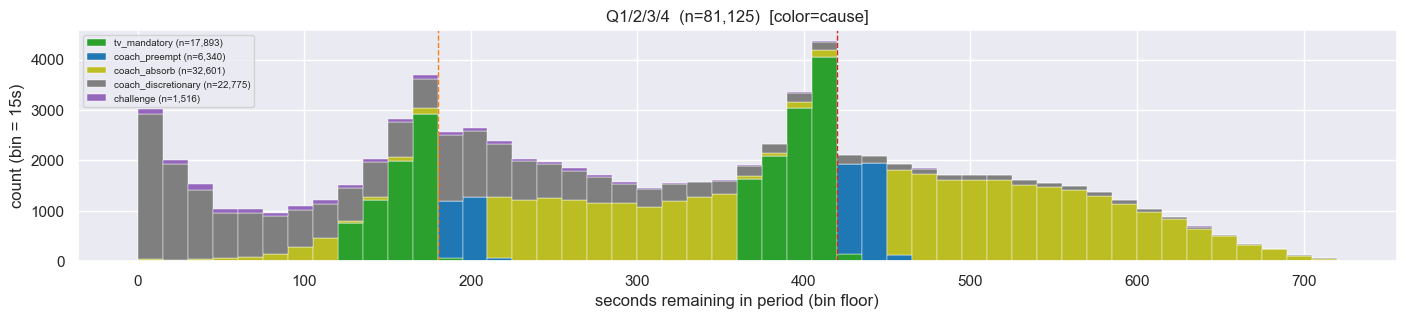

In [26]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, color_by="cause", combine_periods=True)
fig

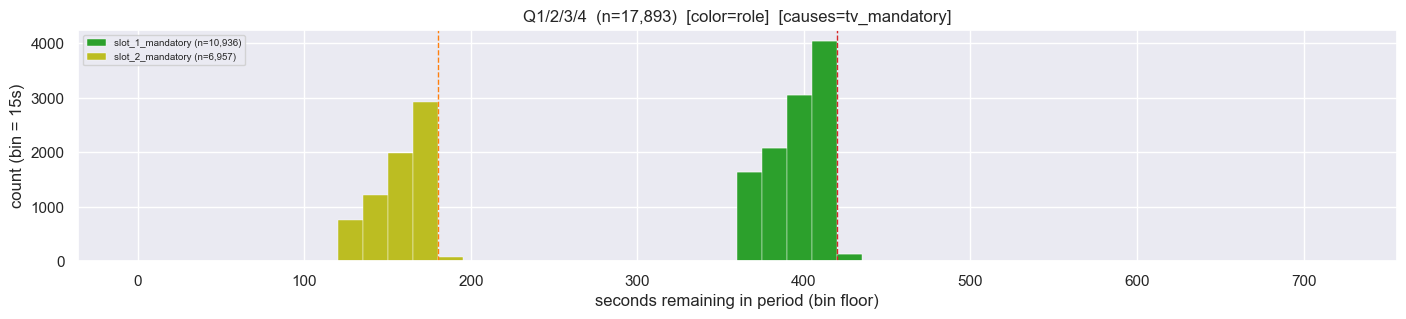

In [27]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("tv_mandatory",), combine_periods=True)
fig

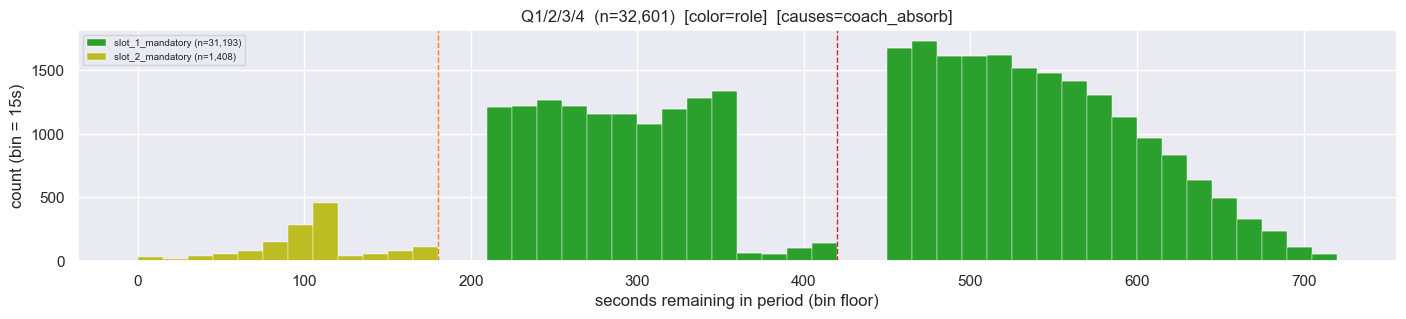

In [28]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("coach_absorb",), combine_periods=True)
fig

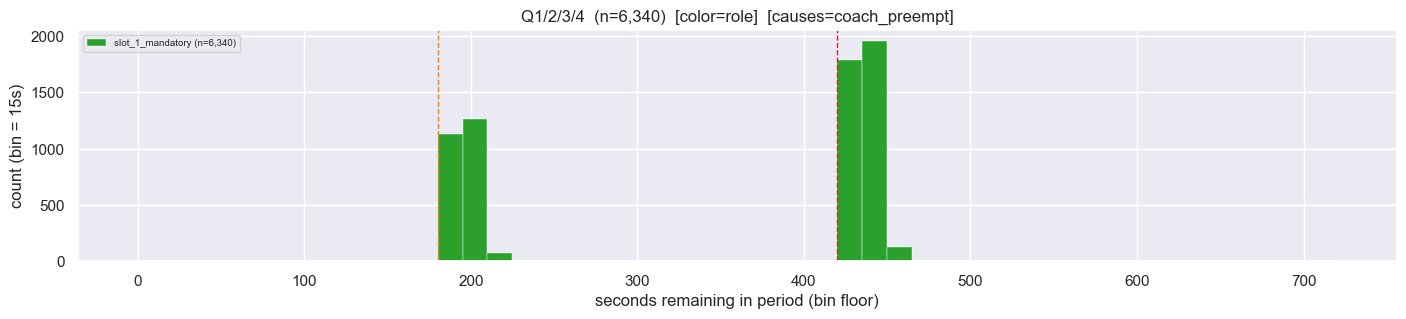

In [29]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("coach_preempt",), combine_periods=True)
fig

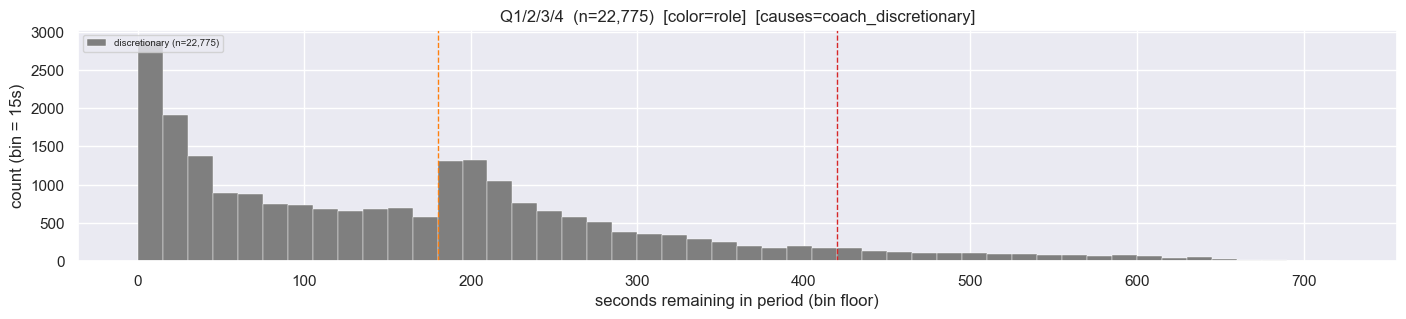

In [30]:
fig, _ = TimeoutInjectionPlots.plot_role_vs_sr(classified, causes=("coach_discretionary",), combine_periods=True)
fig